# $(SASA) Models - Kmeans$

In [1]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import pickle
import numpy as np
import pandas as pd

from pmbrl.model2 import Base_Line_Simple_Model
# from pmbrl.model2 import Model, Regularized_Reference_Loss
from pmbrl.data import Experiment_Data, get_data_expanded

In [2]:
data = Experiment_Data()

data.load(path='../training_data.csv')
data.build_training_dataset()

,step,episode,p,s,a,r,s_,a_,r_,s__
265,17,9,"(0.0614156820293939, 0.6127438843111195)","(0.013, -0.221, 0.058, 0.411)",1,1.0,"(0.009, -0.029, 0.067, 0.194)",0.0,1.0,"(0.008, -0.222, 0.07, 0.442)"
1313,35,53,"(0.2444473003074412, 0.4846825463128728)","(-0.006, 0.227, -0.024, -0.46)",1,1.0,"(-0.002, 0.424, -0.033, -0.806)",1.0,1.0,"(0.007, 0.622, -0.049, -1.155)"
770,15,27,"(0.3197179553472873, 0.8108021737171857)","(0.065, 0.182, -0.12, -0.439)",1,1.0,"(0.069, 0.375, -0.129, -0.679)",0.0,1.0,"(0.076, 0.185, -0.143, -0.497)"
668,56,23,"(0.2125978932043111, 0.6111562190979459)","(-0.444, -1.458, -0.109, 0.356)",0,1.0,"(-0.473, -1.651, -0.102, 0.585)",1.0,1.0,"(-0.506, -1.456, -0.09, 0.297)"
1156,54,46,"(0.5759890361457483, 0.539204361971833)","(-0.276, 0.358, 0.109, -0.8)",0,1.0,"(-0.269, 0.156, 0.093, -0.341)",1.0,1.0,"(-0.266, 0.354, 0.086, -0.712)"
...,...,...,...,...,...,...,...,...,...,...
629,17,23,"(0.2125978932043111, 0.6111562190979459)","(0.026, -0.166, -0.089, -0.071)",0,1.0,"(0.023, -0.359, -0.091, 0.163)",0.0,1.0,"(0.015, -0.551, -0.088, 0.397)"
848,0,34,"(0.2116904176933263, 0.2781477121195577)","(-0.05, 0.037, -0.026, 0.015)",1,1.0,"(-0.049, 0.246, -0.025, -0.573)",1.0,1.0,"(-0.044, 0.454, -0.037, -1.162)"
1007,43,40,"(0.2813661297145153, 1.1191562797649632)","(0.037, -0.567, 0.153, 0.866)",1,1.0,"(0.025, -0.38, 0.171, 0.743)",0.0,1.0,"(0.018, -0.569, 0.185, 0.918)"
719,6,25,"(0.5173094938064725, 0.406281554379609)","(-0.06, -0.459, 0.019, 0.992)",0,1.0,"(-0.069, -0.665, 0.038, 1.521)",1.0,1.0,"(-0.083, -0.461, 0.069, 1.024)"


In [3]:
expansions = {
    's': ['s0', 's1', 's2', 's3'],
    's_': ['s_0', 's_1', 's_2', 's_3'],
    'p': ['p0', 'p1'],
}

df = get_data_expanded(data.build_training_dataset(), expansions)
# df = df.loc[df['episode']<15].copy()
df

,step,episode,p,s,a,r,s_,a_,r_,s__,s0,s1,s2,s3,s_0,s_1,s_2,s_3,p0,p1
2033,27,80,"(0.077800491974935, 0.5006250071926374)","(-0.027, -0.233, -0.052, 0.076)",0,1.0,"(-0.032, -0.427, -0.051, 0.347)",0.0,1.0,"(-0.041, -0.621, -0.044, 0.618)",-0.027,-0.233,-0.052,0.076,-0.032,-0.427,-0.051,0.347,0.077800,0.500625
619,7,23,"(0.2125978932043111, 0.6111562190979459)","(0.025, -0.175, -0.053, 0.132)",1,1.0,"(0.022, 0.019, -0.05, -0.143)",1.0,1.0,"(0.022, 0.213, -0.053, -0.418)",0.025,-0.175,-0.053,0.132,0.022,0.019,-0.050,-0.143,0.212598,0.611156
1888,17,74,"(0.0909739944949207, 0.7220456982231811)","(-0.068, -0.58, 0.157, 0.835)",1,1.0,"(-0.079, -0.391, 0.173, 0.67)",1.0,1.0,"(-0.087, -0.202, 0.187, 0.51)",-0.068,-0.580,0.157,0.835,-0.079,-0.391,0.173,0.670,0.090974,0.722046
916,1,38,"(0.4545373771214862, 0.5810082803318615)","(-0.002, 0.172, 0.022, -0.318)",0,1.0,"(0.002, -0.026, 0.016, 0.03)",0.0,1.0,"(0.001, -0.223, 0.017, 0.376)",-0.002,0.172,0.022,-0.318,0.002,-0.026,0.016,0.030,0.454537,0.581008
1737,11,69,"(0.1433033517266329, 1.8075969481187537)","(-0.032, -0.185, 0.064, 0.152)",0,1.0,"(-0.036, -0.371, 0.067, 0.241)",1.0,1.0,"(-0.044, -0.185, 0.072, 0.164)",-0.032,-0.185,0.064,0.152,-0.036,-0.371,0.067,0.241,0.143303,1.807597
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1937,18,77,"(0.1064004661572971, 0.3173964772630564)","(0.007, -0.37, -0.067, 0.224)",0,1.0,"(-0.001, -0.571, -0.062, 0.652)",1.0,1.0,"(-0.012, -0.367, -0.049, 0.159)",0.007,-0.370,-0.067,0.224,-0.001,-0.571,-0.062,0.652,0.106400,0.317396
355,1,13,"(0.2403247570594251, 0.7298838219922094)","(0.037, -0.157, 0.031, 0.207)",1,1.0,"(0.034, 0.035, 0.035, -0.009)",0.0,1.0,"(0.035, -0.157, 0.035, 0.223)",0.037,-0.157,0.031,0.207,0.034,0.035,0.035,-0.009,0.240325,0.729884
319,21,11,"(0.7542102482276688, 0.9476222740008828)","(0.025, 0.589, -0.099, -1.017)",0,1.0,"(0.037, 0.396, -0.12, -0.756)",1.0,1.0,"(0.045, 0.592, -0.135, -1.084)",0.025,0.589,-0.099,-1.017,0.037,0.396,-0.120,-0.756,0.754210,0.947622
198,82,6,"(0.2451557536988955, 1.3793967951445396)","(-0.381, 0.002, -0.045, -0.406)",0,1.0,"(-0.381, -0.185, -0.053, -0.294)",0.0,1.0,"(-0.385, -0.372, -0.059, -0.182)",-0.381,0.002,-0.045,-0.406,-0.381,-0.185,-0.053,-0.294,0.245156,1.379397


In [4]:
def dist(orig, dest):
    return np.sqrt(np.pow(df[dest] - df[orig], 2))

df['dist_s0'] = dist('s0', 's_0') 
df['dist_s1'] = dist('s1', 's_1')
df['dist_s2'] = dist('s2', 's_2')
df['dist_s3'] = dist('s3', 's_3')

# df = df[[
#     'episode',
#     'p0', 'p1',
#     'dist_s0', 'dist_s1', 'dist_s2', 'dist_s3'
# ]].groupby(['episode']).mean()
df

,step,episode,p,s,a,r,s_,a_,r_,s__,...,s_0,s_1,s_2,s_3,p0,p1,dist_s0,dist_s1,dist_s2,dist_s3
970,6,40,"(0.2813661297145153, 1.1191562797649632)","(0.044, 0.018, 0.026, -0.006)",1,1.0,"(0.044, 0.206, 0.026, -0.153)",0.0,1.0,"(0.049, 0.017, 0.023, 0.002)",...,0.044,0.206,0.026,-0.153,0.281366,1.119156,0.000,0.188,0.000,0.147
1371,2,56,"(0.1186105346284869, 0.3162139843428207)","(0.017, -0.051, 0.059, 0.071)",1,1.0,"(0.016, 0.151, 0.06, -0.367)",1.0,1.0,"(0.019, 0.353, 0.053, -0.805)",...,0.016,0.151,0.060,-0.367,0.118611,0.316214,0.001,0.202,0.001,0.438
1162,60,46,"(0.5759890361457483, 0.539204361971833)","(-0.23, 0.751, 0.017, -1.433)",1,1.0,"(-0.215, 0.951, -0.012, -1.842)",0.0,1.0,"(-0.196, 0.751, -0.049, -1.43)",...,-0.215,0.951,-0.012,-1.842,0.575989,0.539204,0.015,0.200,0.029,0.409
2360,24,93,"(0.2048148528652186, 0.3945260327599418)","(0.042, -0.399, 0.032, 0.87)",1,1.0,"(0.034, -0.2, 0.049, 0.482)",1.0,1.0,"(0.03, -0.001, 0.059, 0.102)",...,0.034,-0.200,0.049,0.482,0.204815,0.394526,0.008,0.199,0.017,0.388
1052,20,43,"(0.1333037473628499, 0.2612549147852426)","(-0.042, -0.448, 0.013, 0.874)",0,1.0,"(-0.051, -0.656, 0.031, 1.457)",0.0,1.0,"(-0.064, -0.864, 0.06, 2.049)",...,-0.051,-0.656,0.031,1.457,0.133304,0.261255,0.009,0.208,0.018,0.583
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
396,4,14,"(0.3661060257466248, 0.7420528554871)","(0.009, -0.787, 0.053, 1.043)",0,1.0,"(-0.007, -0.98, 0.074, 1.301)",1.0,1.0,"(-0.027, -0.788, 0.1, 1.077)",...,-0.007,-0.980,0.074,1.301,0.366106,0.742053,0.016,0.193,0.021,0.258
591,19,22,"(0.1859246409325834, 0.509421113235871)","(-0.04, -0.59, -0.096, 0.328)",0,1.0,"(-0.052, -0.784, -0.089, 0.601)",0.0,1.0,"(-0.068, -0.978, -0.077, 0.877)",...,-0.052,-0.784,-0.089,0.601,0.185925,0.509421,0.012,0.194,0.007,0.273
2015,9,80,"(0.077800491974935, 0.5006250071926374)","(-0.016, -0.239, -0.007, 0.213)",0,1.0,"(-0.021, -0.434, -0.003, 0.498)",1.0,1.0,"(-0.029, -0.239, 0.007, 0.21)",...,-0.021,-0.434,-0.003,0.498,0.077800,0.500625,0.005,0.195,0.004,0.285
447,12,18,"(0.3051056444765603, 0.3905400892149759)","(0.045, 0.046, -0.178, -0.596)",1,1.0,"(0.046, 0.251, -0.19, -1.109)",0.0,1.0,"(0.051, 0.054, -0.212, -0.769)",...,0.046,0.251,-0.190,-1.109,0.305106,0.390540,0.001,0.205,0.012,0.513


# Initial Inference

In [4]:
k = 5
models = [Base_Line_Simple_Model() for _ in range(k)]

In [6]:
def predict(model):
    prediction_dataset = df.copy()
    prediction_dataset[model.grouped_targets_lables] = prediction_dataset.apply(lambda row: data._predict_from_row(row, model), axis=1, result_type='expand')
    return prediction_dataset

predictions = [predict(m) for m in models]

In [7]:
results = data.get_evaluation_metrics(predictions[0], p=False)
results.head()

,step,episode,p,s,a,r,s_,a_,r_,s__,...,rse_s1,rse_s2,rse_s3,rse_r,rse_s0_normalized,rse_s1_normalized,rse_s2_normalized,rse_s3_normalized,rse,rse_normalized
2033,27,80,"(0.077800491974935, 0.5006250071926374)","(-0.027, -0.233, -0.052, 0.076)",0,1.0,"(-0.032, -0.427, -0.051, 0.347)",0.0,1.0,"(-0.041, -0.621, -0.044, 0.618)",...,1.063,0.021,0.672,1.0,0.439634,0.604286,0.549161,0.613699,1.843,0.551695
619,7,23,"(0.2125978932043111, 0.6111562190979459)","(0.025, -0.175, -0.053, 0.132)",1,1.0,"(0.022, 0.019, -0.05, -0.143)",1.0,1.0,"(0.022, 0.213, -0.053, -0.418)",...,0.449,0.203,0.468,1.0,0.423397,0.497299,0.985612,0.601453,1.168,0.626940
1888,17,74,"(0.0909739944949207, 0.7220456982231811)","(-0.068, -0.58, 0.157, 0.835)",1,1.0,"(-0.079, -0.391, 0.173, 0.67)",1.0,1.0,"(-0.087, -0.202, 0.187, 0.51)",...,0.881,0.406,0.361,1.0,0.448376,0.572574,1.472422,0.595029,1.756,0.772100
916,1,38,"(0.4545373771214862, 0.5810082803318615)","(-0.002, 0.172, 0.022, -0.318)",0,1.0,"(0.002, -0.026, 0.016, 0.03)",0.0,1.0,"(0.001, -0.223, 0.017, 0.376)",...,0.613,0.093,0.501,1.0,0.456286,0.525876,0.721823,0.603434,1.334,0.576855
1737,11,69,"(0.1433033517266329, 1.8075969481187537)","(-0.032, -0.185, 0.064, 0.152)",0,1.0,"(-0.036, -0.371, 0.067, 0.241)",1.0,1.0,"(-0.044, -0.185, 0.072, 0.164)",...,0.873,0.308,0.055,1.0,0.407577,0.571180,1.237410,0.576660,1.246,0.698207


In [9]:
prediction_dataset = df.copy()
for i, predict in enumerate(predictions):
    prediction_dataset[f'estimated_s_model_{i}'] = predict['estimated_s']
    
    results = data.get_evaluation_metrics(predict, p=False)
    prediction_dataset[f'rse_model_{i}'] = results['rse']
    prediction_dataset[f'rse_normalized_model_{i}'] = results['rse_normalized']

    prediction_dataset[f'rse_s0_model_{i}'] = results['rse_s0']
    prediction_dataset[f'rse_s1_model_{i}'] = results['rse_s1']
    prediction_dataset[f'rse_s2_model_{i}'] = results['rse_s2']
    prediction_dataset[f'rse_s3_model_{i}'] = results['rse_s3']

    prediction_dataset[f'rse_s0_normalized_model_{i}'] = results['rse_s0_normalized']
    prediction_dataset[f'rse_s1_normalized_model_{i}'] = results['rse_s1_normalized']
    prediction_dataset[f'rse_s2_normalized_model_{i}'] = results['rse_s2_normalized']
    prediction_dataset[f'rse_s3_normalized_model_{i}'] = results['rse_s3_normalized']


prediction_dataset.head()

,step,episode,p,s,a,r,s_,a_,r_,s__,...,rse_model_4,rse_normalized_model_4,rse_s0_model_4,rse_s1_model_4,rse_s2_model_4,rse_s3_model_4,rse_s0_normalized_model_4,rse_s1_normalized_model_4,rse_s2_normalized_model_4,rse_s3_normalized_model_4
2033,27,80,"(0.077800491974935, 0.5006250071926374)","(-0.027, -0.233, -0.052, 0.076)",0,1.0,"(-0.032, -0.427, -0.051, 0.347)",0.0,1.0,"(-0.041, -0.621, -0.044, 0.618)",...,1.796,0.566244,0.092,0.640,0.067,0.997,0.441715,0.530580,0.659472,0.633209
619,7,23,"(0.2125978932043111, 0.6111562190979459)","(0.025, -0.175, -0.053, 0.132)",1,1.0,"(0.022, 0.019, -0.05, -0.143)",1.0,1.0,"(0.022, 0.213, -0.053, -0.418)",...,0.436,0.550597,0.053,0.212,0.102,0.069,0.425479,0.456003,0.743405,0.577500
1888,17,74,"(0.0909739944949207, 0.7220456982231811)","(-0.068, -0.58, 0.157, 0.835)",1,1.0,"(-0.079, -0.391, 0.173, 0.67)",1.0,1.0,"(-0.087, -0.202, 0.187, 0.51)",...,1.570,0.627347,0.059,0.320,0.198,0.993,0.427977,0.474821,0.973621,0.632969
916,1,38,"(0.4545373771214862, 0.5810082803318615)","(-0.002, 0.172, 0.022, -0.318)",0,1.0,"(0.002, -0.026, 0.016, 0.03)",0.0,1.0,"(0.001, -0.223, 0.017, 0.376)",...,1.177,0.578283,0.142,0.187,0.118,0.730,0.462531,0.451647,0.781775,0.617181
1737,11,69,"(0.1433033517266329, 1.8075969481187537)","(-0.032, -0.185, 0.064, 0.152)",0,1.0,"(-0.036, -0.371, 0.067, 0.241)",1.0,1.0,"(-0.044, -0.185, 0.072, 0.164)",...,1.093,0.529005,0.104,0.282,0.037,0.670,0.446711,0.468200,0.587530,0.613579


In [55]:
agg_results = prediction_dataset[['episode'] + [
    f'rse_model_{i}' for i,_ in enumerate(models)
]].groupby('episode').mean().reset_index()
#     'rse_model_0',
#     'rse_model_1',
#     'rse_model_2',
#     'rse_model_3',
#     'rse_model_4',
# ]].groupby('episode').mean().reset_index()

agg_results['best_model'] = agg_results.apply(lambda row: np.argmin(row.values), axis=1)

agg_results['best_model'].value_counts()

best_model
2    44
1    31
5    20
4     4
0     1
Name: count, dtype: int64

In [56]:
agg_results.head()

,episode,rse_model_0,rse_model_1,rse_model_2,rse_model_3,rse_model_4,best_model
0,0,2.271400,1.610800,2.581200,2.057600,2.431400,0
1,1,0.992538,1.755923,1.534154,1.906038,1.146846,1
2,2,1.983318,1.148591,2.192455,1.513227,1.986909,2
3,3,1.957000,1.678562,1.948313,1.853625,1.826250,2
4,4,2.197000,1.995429,2.184429,2.194929,2.117714,2


In [57]:
for i,_ in enumerate(models):
    best_episodes = agg_results.loc[agg_results[f'rse_model_{i}'].rank(ascending=False).values < 15].episode
    agg_results[f'used_for_model_{i}'] = agg_results.apply(lambda row: row.episode in best_episodes.values, axis=1)

agg_results.head()

# epis_per_model = [agg_results.loc[agg_results[f'rse_model_{i}'].rank(ascending=False).values < 15].reset_index().episode for i,_ in enumerate(models)]
# epis_per_model

,episode,rse_model_0,rse_model_1,rse_model_2,rse_model_3,rse_model_4,best_model,used_for_model_0,used_for_model_1,used_for_model_2,used_for_model_3,used_for_model_4
0,0,2.271400,1.610800,2.581200,2.057600,2.431400,0,False,False,False,False,False
1,1,0.992538,1.755923,1.534154,1.906038,1.146846,1,False,False,False,False,False
2,2,1.983318,1.148591,2.192455,1.513227,1.986909,2,False,False,False,False,False
3,3,1.957000,1.678562,1.948313,1.853625,1.826250,2,False,False,False,False,False
4,4,2.197000,1.995429,2.184429,2.194929,2.117714,2,False,False,False,False,False


In [58]:
agg_results.loc[agg_results['episode']==10]

,episode,rse_model_0,rse_model_1,rse_model_2,rse_model_3,rse_model_4,best_model,used_for_model_0,used_for_model_1,used_for_model_2,used_for_model_3,used_for_model_4
10,10,2.981286,2.986429,3.660571,3.831357,3.249214,1,True,True,True,True,True


In [59]:
agg_results.loc[
    (
        # agg_results['used_for_model_0']==False &
        # agg_results['used_for_model_1']==False &
        # agg_results['used_for_model_2']==False &
        # agg_results['used_for_model_3']==False &
        agg_results['used_for_model_4']==False
    )
]

,episode,rse_model_0,rse_model_1,rse_model_2,rse_model_3,rse_model_4,best_model,used_for_model_0,used_for_model_1,used_for_model_2,used_for_model_3,used_for_model_4
0,0,2.271400,1.610800,2.581200,2.057600,2.431400,0,False,False,False,False,False
1,1,0.992538,1.755923,1.534154,1.906038,1.146846,1,False,False,False,False,False
2,2,1.983318,1.148591,2.192455,1.513227,1.986909,2,False,False,False,False,False
3,3,1.957000,1.678562,1.948313,1.853625,1.826250,2,False,False,False,False,False
4,4,2.197000,1.995429,2.184429,2.194929,2.117714,2,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
93,93,1.328146,1.675902,1.534268,1.808366,1.171659,5,False,False,False,False,False
94,94,1.442868,1.749377,2.006660,1.944604,1.570302,1,False,False,False,False,False
96,96,1.930412,1.614588,2.165765,1.854765,1.932176,2,False,False,False,False,False
97,97,2.189267,1.755400,2.444467,2.004600,2.245267,2,False,False,False,False,False


## Kmeans

In [ ]:
# X = df[['dist_s1', 'dist_s3']]
X = prediction_dataset[['rse_s1_normalized_model_', 'dist_s3']]
# X = df.loc[df['a']==0].copy()[['dist_s1', 'dist_s3']]

kmeans = KMeans(n_clusters=k, random_state=1, n_init="auto").fit(X)

for i, label in enumerate(np.unique(kmeans.labels_)):
    df.loc[kmeans.labels_ == label, 'group'] = i

In [6]:
X_p = df[['p0', 'p1']]
# X_p = df.loc[df['a']==0].copy()[['p0', 'p1']]
kmeans_p = KMeans(n_clusters=k, random_state=1, n_init="auto").fit(X_p)

In [7]:
def plot_clusters(axs, cluster_model, d, cols, title, labels, colors:list[str] = ['r', 'b', 'y', 'g', 'gray']):
        # avg distances
        for i, label in enumerate(np.unique(cluster_model.labels_)):
            cluster_points = d[cluster_model.labels_ == label]
            axs.scatter(cluster_points[cols[0]], cluster_points[cols[1]], color=colors[i], marker='.')
        axs.scatter(cluster_model.cluster_centers_[:,0], cluster_model.cluster_centers_[:,1], color='black', marker='x')

        axs.set_title(title)
        axs.set_xlabel(labels[0])
        axs.set_ylabel(labels[1])

        return axs

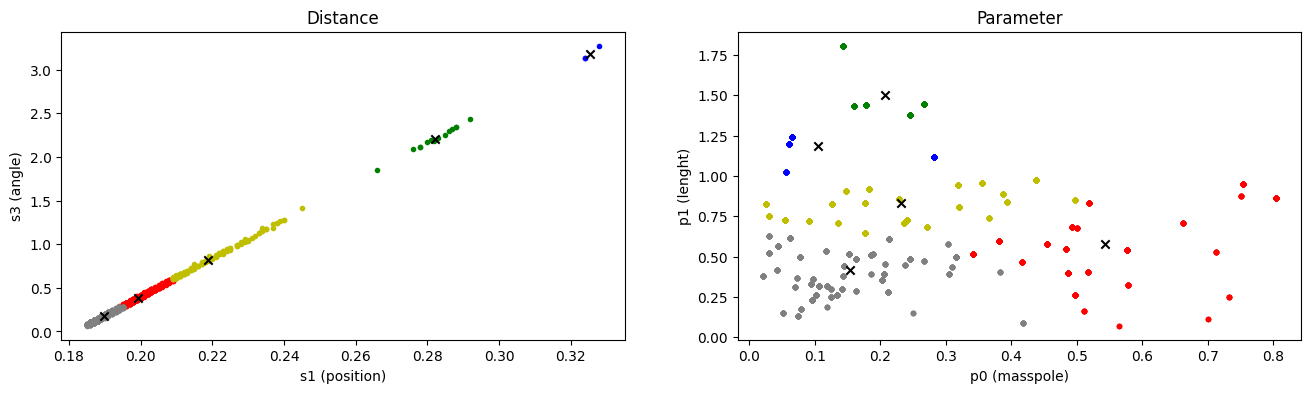

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(16, 4))
# plot_clusters(axs, df.loc[df['a'] == 0].copy())
plot_clusters(axs[0], cluster_model=kmeans, d=X, cols=['dist_s1', 'dist_s3'], title='Distance', labels=['s1 (velocity)', 's3 (anglular velocity)'])
# plot_clusters(axs[0], cluster_model=kmeans, d=X, cols=['dist_s0', 'dist_s2'], title='Distance', labels=['s0 (position)', 's2 (angle)'])
plot_clusters(axs[1], cluster_model=kmeans_p, d=X_p, cols=['p0', 'p1'], title='Parameter', labels=['p0 (masspole)', 'p1 (lenght)'])

plt.show()

# Train Models

In [9]:
# train_dataset = df[[
#     's0', 's1', 's2', 's3', 'a', 's_0', 's_1', 's_2', 's_3', 'p0', 'p1', 'group'
# ]]
train_dataset = df[[
    's', 's_', 's__', 'a', 'a_', 'r', 'p', 'group'
]]

In [10]:
models = [Base_Line_Simple_Model() for _ in train_dataset.group.unique()]
train_data = [None for _ in models]


for g, model in enumerate(models):
    print('train cluster: ', g)
    group_data = train_dataset.loc[train_dataset['group']==g]
    x, y = model.get_features_targets(group_data)
    trainer = model.train(x, y, num_epochs=10000)
    train_data[g] = data.get_training_data(trainer, inference_schema=model.inference_schema)

train_data[0].head()

train cluster:  0
train cluster:  1
train cluster:  2
train cluster:  3
train cluster:  4


,epoch,mse_s,transition,reward
0,0,"[0.020463421940803528, 0.388942152261734, 0.14...",1.563728,2.061748
1,1,"[0.019866574555635452, 0.38462910056114197, 0....",1.547830,2.048027
2,2,"[0.0192837156355381, 0.3803413510322571, 0.136...",1.532055,2.034430
3,3,"[0.018715467303991318, 0.3760780990123749, 0.1...",1.516403,2.020960
4,4,"[0.01816209778189659, 0.3718392848968506, 0.12...",1.500875,2.007625


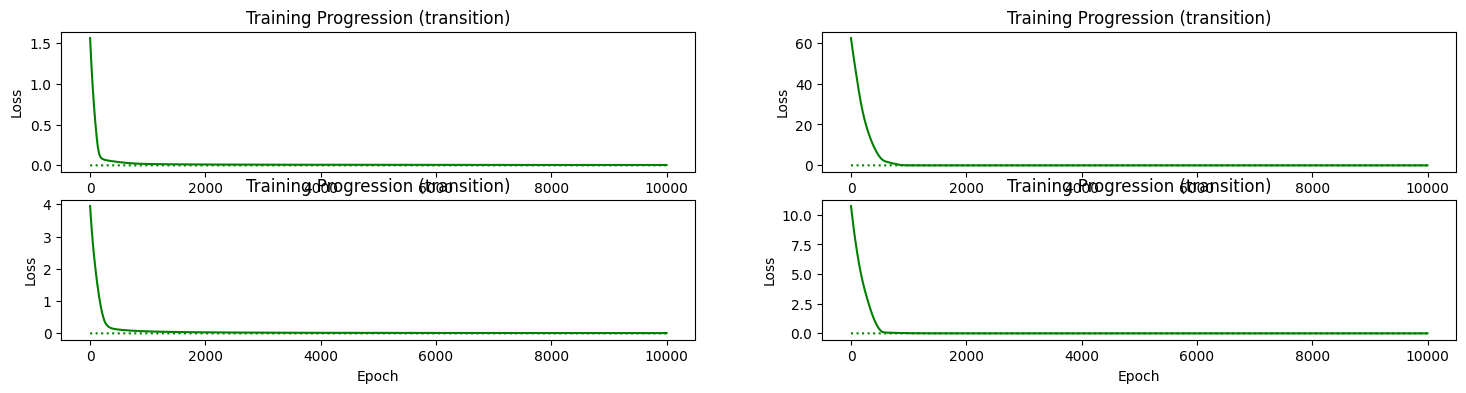

In [11]:
fig, axs = plt.subplots(2, 2, figsize=(18, 4))

data.plot_training_loss(axs[0][0], train_data[0].transition)
data.plot_training_loss(axs[0][1], train_data[1].transition)
data.plot_training_loss(axs[1][0], train_data[2].transition)
data.plot_training_loss(axs[1][1], train_data[3].transition)

plt.show()

# Evaluation

In [13]:
data = Experiment_Data()

data.load(path='../testing_data.csv')
data.build_training_dataset()

,step,episode,p,s,a,r,s_,a_,r_,s__
572,2,30,"(0.5284851379408768, 0.998795269316345)","(-0.031, -0.389, -0.036, 0.417)",0,1.0,"(-0.038, -0.58, -0.028, 0.621)",0.0,1.0,"(-0.05, -0.772, -0.016, 0.828)"
1799,33,89,"(0.1964578206703505, 1.7230322017264583)","(0.121, 0.212, -0.037, -0.109)",0,1.0,"(0.125, 0.026, -0.039, -0.022)",1.0,1.0,"(0.126, 0.212, -0.04, -0.117)"
1670,8,84,"(0.2011569802355368, 0.4470007793802826)","(0.053, 0.039, -0.008, 0.067)",1,1.0,"(0.054, 0.237, -0.007, -0.29)",0.0,1.0,"(0.059, 0.039, -0.012, 0.061)"
1597,14,81,"(0.2055036802915485, 0.7357574690187201)","(0.011, 0.731, 0.032, -0.713)",0,1.0,"(0.026, 0.539, 0.017, -0.49)",0.0,1.0,"(0.037, 0.348, 0.008, -0.27)"
479,45,26,"(0.1168448454824361, 0.6199561479617748)","(-0.07, 0.155, 0.0, 0.029)",1,1.0,"(-0.066, 0.348, 0.001, -0.21)",1.0,1.0,"(-0.059, 0.54, -0.003, -0.449)"
...,...,...,...,...,...,...,...,...,...,...
2040,11,98,"(0.1955406148449595, 0.6245501454716056)","(0.01, -0.154, -0.004, 0.136)",1,1.0,"(0.007, 0.039, -0.002, -0.117)",1.0,1.0,"(0.008, 0.233, -0.004, -0.369)"
2056,27,98,"(0.1955406148449595, 0.6245501454716056)","(0.062, -0.528, -0.115, 0.375)",1,1.0,"(0.052, -0.334, -0.107, 0.094)",0.0,1.0,"(0.045, -0.526, -0.105, 0.315)"
70,7,5,"(0.430048372063981, 1.1278028896353474)","(0.039, 0.599, -0.005, -0.53)",0,1.0,"(0.051, 0.41, -0.015, -0.36)",1.0,1.0,"(0.059, 0.6, -0.022, -0.533)"
1090,18,51,"(0.0298100647764461, 0.4293440754325293)","(0.068, -0.772, -0.161, 0.541)",0,1.0,"(0.053, -0.966, -0.15, 0.805)",0.0,1.0,"(0.034, -1.16, -0.134, 1.073)"


In [14]:
expansions = {
    's': ['s0', 's1', 's2', 's3'],
    's_': ['s_0', 's_1', 's_2', 's_3'],
    'p': ['p0', 'p1'],
}

df = get_data_expanded(data.build_training_dataset(), expansions)
df.head()

,step,episode,p,s,a,r,s_,a_,r_,s__,s0,s1,s2,s3,s_0,s_1,s_2,s_3,p0,p1
1706,6,85,"(0.2282907152832285, 0.2987087615494261)","(-0.0, 0.828, -0.125, -2.287)",1,1.0,"(0.016, 1.036, -0.171, -2.892)",1.0,1.0,"(0.037, 1.245, -0.229, -3.517)",-0.000,0.828,-0.125,-2.287,0.016,1.036,-0.171,-2.892,0.228291,0.298709
2004,10,97,"(0.1590895790518159, 0.4779544798666842)","(0.02, 0.383, 0.01, -0.532)",0,1.0,"(0.027, 0.187, -0.001, -0.208)",1.0,1.0,"(0.031, 0.383, -0.005, -0.529)",0.020,0.383,0.010,-0.532,0.027,0.187,-0.001,-0.208,0.159090,0.477954
796,47,38,"(0.1011387519285949, 1.9659375713404728)","(0.037, -0.583, 0.034, 0.282)",0,1.0,"(0.025, -0.768, 0.04, 0.359)",0.0,1.0,"(0.01, -0.953, 0.047, 0.437)",0.037,-0.583,0.034,0.282,0.025,-0.768,0.040,0.359,0.101139,1.965938
895,19,43,"(0.0242491433958297, 0.9266927708557562)","(0.146, 1.284, -0.183, -1.246)",1,1.0,"(0.172, 1.474, -0.208, -1.422)",0.0,1.0,"(0.202, 1.287, -0.236, -1.308)",0.146,1.284,-0.183,-1.246,0.172,1.474,-0.208,-1.422,0.024249,0.926693
1811,45,89,"(0.1964578206703505, 1.7230322017264583)","(0.262, 0.959, -0.113, -0.546)",0,1.0,"(0.281, 0.773, -0.124, -0.467)",1.0,1.0,"(0.296, 0.96, -0.134, -0.569)",0.262,0.959,-0.113,-0.546,0.281,0.773,-0.124,-0.467,0.196458,1.723032


In [15]:
df['dist_s0'] = dist('s0', 's_0') 
df['dist_s1'] = dist('s1', 's_1')
df['dist_s2'] = dist('s2', 's_2')
df['dist_s3'] = dist('s3', 's_3')

df.head()

,step,episode,p,s,a,r,s_,a_,r_,s__,...,s_0,s_1,s_2,s_3,p0,p1,dist_s0,dist_s1,dist_s2,dist_s3
1706,6,85,"(0.2282907152832285, 0.2987087615494261)","(-0.0, 0.828, -0.125, -2.287)",1,1.0,"(0.016, 1.036, -0.171, -2.892)",1.0,1.0,"(0.037, 1.245, -0.229, -3.517)",...,0.016,1.036,-0.171,-2.892,0.228291,0.298709,0.016,0.208,0.046,0.605
2004,10,97,"(0.1590895790518159, 0.4779544798666842)","(0.02, 0.383, 0.01, -0.532)",0,1.0,"(0.027, 0.187, -0.001, -0.208)",1.0,1.0,"(0.031, 0.383, -0.005, -0.529)",...,0.027,0.187,-0.001,-0.208,0.159090,0.477954,0.007,0.196,0.011,0.324
796,47,38,"(0.1011387519285949, 1.9659375713404728)","(0.037, -0.583, 0.034, 0.282)",0,1.0,"(0.025, -0.768, 0.04, 0.359)",0.0,1.0,"(0.01, -0.953, 0.047, 0.437)",...,0.025,-0.768,0.040,0.359,0.101139,1.965938,0.012,0.185,0.006,0.077
895,19,43,"(0.0242491433958297, 0.9266927708557562)","(0.146, 1.284, -0.183, -1.246)",1,1.0,"(0.172, 1.474, -0.208, -1.422)",0.0,1.0,"(0.202, 1.287, -0.236, -1.308)",...,0.172,1.474,-0.208,-1.422,0.024249,0.926693,0.026,0.190,0.025,0.176
1811,45,89,"(0.1964578206703505, 1.7230322017264583)","(0.262, 0.959, -0.113, -0.546)",0,1.0,"(0.281, 0.773, -0.124, -0.467)",1.0,1.0,"(0.296, 0.96, -0.134, -0.569)",...,0.281,0.773,-0.124,-0.467,0.196458,1.723032,0.019,0.186,0.011,0.079


In [16]:
X = df[['dist_s1', 'dist_s3']]

groups = kmeans.predict(X)

# for i, label in enumerate(np.unique(kmeans.labels_)):
    # df.loc[kmeans.labels_ == label, 'group'] = i
df['group'] = groups
df.head()

,step,episode,p,s,a,r,s_,a_,r_,s__,...,s_1,s_2,s_3,p0,p1,dist_s0,dist_s1,dist_s2,dist_s3,group
1706,6,85,"(0.2282907152832285, 0.2987087615494261)","(-0.0, 0.828, -0.125, -2.287)",1,1.0,"(0.016, 1.036, -0.171, -2.892)",1.0,1.0,"(0.037, 1.245, -0.229, -3.517)",...,1.036,-0.171,-2.892,0.228291,0.298709,0.016,0.208,0.046,0.605,2
2004,10,97,"(0.1590895790518159, 0.4779544798666842)","(0.02, 0.383, 0.01, -0.532)",0,1.0,"(0.027, 0.187, -0.001, -0.208)",1.0,1.0,"(0.031, 0.383, -0.005, -0.529)",...,0.187,-0.001,-0.208,0.159090,0.477954,0.007,0.196,0.011,0.324,0
796,47,38,"(0.1011387519285949, 1.9659375713404728)","(0.037, -0.583, 0.034, 0.282)",0,1.0,"(0.025, -0.768, 0.04, 0.359)",0.0,1.0,"(0.01, -0.953, 0.047, 0.437)",...,-0.768,0.040,0.359,0.101139,1.965938,0.012,0.185,0.006,0.077,4
895,19,43,"(0.0242491433958297, 0.9266927708557562)","(0.146, 1.284, -0.183, -1.246)",1,1.0,"(0.172, 1.474, -0.208, -1.422)",0.0,1.0,"(0.202, 1.287, -0.236, -1.308)",...,1.474,-0.208,-1.422,0.024249,0.926693,0.026,0.190,0.025,0.176,4
1811,45,89,"(0.1964578206703505, 1.7230322017264583)","(0.262, 0.959, -0.113, -0.546)",0,1.0,"(0.281, 0.773, -0.124, -0.467)",1.0,1.0,"(0.296, 0.96, -0.134, -0.569)",...,0.773,-0.124,-0.467,0.196458,1.723032,0.019,0.186,0.011,0.079,4


In [17]:
evaluation_dataset = df[[
    's', 's_', 's__', 'a', 'a_', 'r', 'p', 'group'
]]

In [18]:
expanded_data = get_data_expanded(evaluation_dataset, {
                's': ['s0', 's1', 's2', 's3'],
                's_': ['s_0', 's_1', 's_2', 's_3'],
                's__': ['s__0', 's__1', 's__2', 's__3'],
                'p': ['p0', 'p1']
        })

In [19]:
evaluation_dataset[models[0].grouped_targets_lables] = expanded_data.apply(lambda row: data._predict_from_row(row, models[row.group]), axis=1, result_type='expand')
evaluation_dataset.head()

/tmp/ipykernel_10688/530237357.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  evaluation_dataset[models[0].grouped_targets_lables] = expanded_data.apply(lambda row: data._predict_from_row(row, models[row.group]), axis=1, result_type='expand')
/tmp/ipykernel_10688/530237357.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  evaluation_dataset[models[0].grouped_targets_lables] = expanded_data.apply(lambda row: data._predict_from_row(row, models[row.group]), axis=1, result_type='expand')


,s,s_,s__,a,a_,r,p,group,estimated_s,estimated_r
1706,"(-0.0, 0.828, -0.125, -2.287)","(0.016, 1.036, -0.171, -2.892)","(0.037, 1.245, -0.229, -3.517)",1,1.0,1.0,"(0.2282907152832285, 0.2987087615494261)",2,"(0.069, 1.149, -0.22, -3.377)",1.0
2004,"(0.02, 0.383, 0.01, -0.532)","(0.027, 0.187, -0.001, -0.208)","(0.031, 0.383, -0.005, -0.529)",0,1.0,1.0,"(0.1590895790518159, 0.4779544798666842)",0,"(0.032, 0.388, -0.005, -0.573)",1.0
796,"(0.037, -0.583, 0.034, 0.282)","(0.025, -0.768, 0.04, 0.359)","(0.01, -0.953, 0.047, 0.437)",0,0.0,1.0,"(0.1011387519285949, 1.9659375713404728)",4,"(0.01, -0.947, 0.047, 0.528)",1.0
895,"(0.146, 1.284, -0.183, -1.246)","(0.172, 1.474, -0.208, -1.422)","(0.202, 1.287, -0.236, -1.308)",1,0.0,1.0,"(0.0242491433958297, 0.9266927708557562)",4,"(0.2, 1.292, -0.231, -1.27)",1.0
1811,"(0.262, 0.959, -0.113, -0.546)","(0.281, 0.773, -0.124, -0.467)","(0.296, 0.96, -0.134, -0.569)",0,1.0,1.0,"(0.1964578206703505, 1.7230322017264583)",4,"(0.295, 0.958, -0.138, -0.649)",1.0


In [20]:
results = data.get_evaluation_metrics(evaluation_dataset, p=False)
results.head()

,s,s_,s__,a,a_,r,p,group,estimated_s,estimated_r,...,rse_s1,rse_s2,rse_s3,rse_r,rse_s0_normalized,rse_s1_normalized,rse_s2_normalized,rse_s3_normalized,rse,rse_normalized
1706,"(-0.0, 0.828, -0.125, -2.287)","(0.016, 1.036, -0.171, -2.892)","(0.037, 1.245, -0.229, -3.517)",1,1.0,1.0,"(0.2282907152832285, 0.2987087615494261)",2,"(0.069, 1.149, -0.22, -3.377)",1.0,...,0.096,0.009,0.140,0.0,0.579725,0.549656,0.522782,0.446650,0.277,0.524703
2004,"(0.02, 0.383, 0.01, -0.532)","(0.027, 0.187, -0.001, -0.208)","(0.031, 0.383, -0.005, -0.529)",0,1.0,1.0,"(0.1590895790518159, 0.4779544798666842)",0,"(0.032, 0.388, -0.005, -0.573)",1.0,...,0.005,0.000,0.044,0.0,0.546990,0.527286,0.501199,0.438436,0.050,0.503478
796,"(0.037, -0.583, 0.034, 0.282)","(0.025, -0.768, 0.04, 0.359)","(0.01, -0.953, 0.047, 0.437)",0,0.0,1.0,"(0.1011387519285949, 1.9659375713404728)",4,"(0.01, -0.947, 0.047, 0.528)",1.0,...,0.006,0.000,0.091,0.0,0.545935,0.527532,0.501199,0.442457,0.097,0.504281
895,"(0.146, 1.284, -0.183, -1.246)","(0.172, 1.474, -0.208, -1.422)","(0.202, 1.287, -0.236, -1.308)",1,0.0,1.0,"(0.0242491433958297, 0.9266927708557562)",4,"(0.2, 1.292, -0.231, -1.27)",1.0,...,0.005,0.005,0.038,0.0,0.548046,0.527286,0.513189,0.437922,0.050,0.506611
1811,"(0.262, 0.959, -0.113, -0.546)","(0.281, 0.773, -0.124, -0.467)","(0.296, 0.96, -0.134, -0.569)",0,1.0,1.0,"(0.1964578206703505, 1.7230322017264583)",4,"(0.295, 0.958, -0.138, -0.649)",1.0,...,0.002,0.004,0.080,0.0,0.546990,0.526549,0.510791,0.441516,0.087,0.506462


In [21]:
results[['rse', 'rse_normalized', 
         'rse_s0', 'rse_s0_normalized',
         'rse_s1', 'rse_s1_normalized', 
         'rse_s2', 'rse_s2_normalized',
         'rse_s3', 'rse_s3_normalized']].describe()

,rse,rse_normalized,rse_s0,rse_s0_normalized,rse_s1,rse_s1_normalized,rse_s2,rse_s2_normalized,rse_s3,rse_s3_normalized
count,2127.000000,2127.000000,2127.000000,2127.000000,2127.000000,2127.000000,2127.000000,2127.000000,2127.000000,2127.000000
mean,0.075559,0.506011,0.002529,0.548605,0.006676,0.527698,0.002678,0.507622,0.063676,0.440119
std,0.091205,0.005264,0.004667,0.004929,0.010855,0.002668,0.004934,0.011832,0.081254,0.006953
min,0.002000,0.502051,0.000000,0.545935,0.000000,0.526057,0.000000,0.501199,0.000000,0.434671
25%,0.030000,0.503685,0.001000,0.546990,0.002000,0.526549,0.001000,0.503597,0.021000,0.436468
50%,0.054000,0.504619,0.001000,0.546990,0.004000,0.527040,0.001000,0.503597,0.046000,0.438607
75%,0.087000,0.506273,0.003000,0.549102,0.008000,0.528024,0.003000,0.508393,0.077000,0.441260
max,1.131000,0.603699,0.094000,0.645195,0.156000,0.564405,0.092000,0.721823,0.995000,0.519808


In [22]:
results[['group', 'rse', 'rse_normalized', 
         'rse_s0', 'rse_s0_normalized',
         'rse_s1', 'rse_s1_normalized', 
         'rse_s2', 'rse_s2_normalized',
         'rse_s3', 'rse_s3_normalized']].groupby('group').mean()

,rse,rse_normalized,rse_s0,rse_s0_normalized,rse_s1,rse_s1_normalized,rse_s2,rse_s2_normalized,rse_s3,rse_s3_normalized
group,,,,,,,,,,
0,0.071158,0.505736,0.002153,0.548208,0.006809,0.527731,0.002514,0.507227,0.059682,0.439778
2,0.175155,0.511551,0.003637,0.549776,0.015231,0.529801,0.007518,0.519228,0.148769,0.447400
3,0.443182,0.531166,0.028955,0.576510,0.044682,0.537041,0.018864,0.546436,0.350682,0.464677
4,0.051072,0.504581,0.002023,0.548070,0.004205,0.527091,0.001494,0.504782,0.043350,0.438380
